In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [3]:
df_train = pd.read_csv('/content/drive/MyDrive/archive/fraudTrain_cleaned.csv')
print(f"Dataset shape: {df_train.shape}")
print(f"\nFraud distribution:")
print(df_train['is_fraud'].value_counts())
print(f"\nFraud rate: {df_train['is_fraud'].mean() * 100:.2f}%")

Dataset shape: (1296675, 29)

Fraud distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud rate: 0.58%


In [4]:
df = df_train.copy()

# Encode category
le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])

# ============================================================
# USER-RELATIVE FEATURES
# ============================================================
# How unusual is this transaction compared to THIS user's history?

# User statistics
user_stats = df.groupby('cc_num')['amt'].agg(['mean', 'std', 'median', 'count']).reset_index()
user_stats.columns = ['cc_num', 'user_mean_amt', 'user_std_amt', 'user_median_amt', 'user_txn_count']
user_stats['user_std_amt'] = user_stats['user_std_amt'].fillna(1)  # avoid division by zero

df = df.merge(user_stats, on='cc_num', how='left')

# Z-score: how many std devs is this transaction from user's mean?
df['user_amt_zscore'] = (df['amt'] - df['user_mean_amt']) / df['user_std_amt']

# Ratio: how many times the user's median is this transaction?
df['user_amt_ratio'] = df['amt'] / (df['user_median_amt'] + 1)  # +1 to avoid div by zero

print("User-relative features created:")
print(f"  user_amt_zscore — range: [{df['user_amt_zscore'].min():.1f}, {df['user_amt_zscore'].max():.1f}]")
print(f"  user_amt_ratio  — range: [{df['user_amt_ratio'].min():.1f}, {df['user_amt_ratio'].max():.1f}]")

User-relative features created:
  user_amt_zscore — range: [-2.8, 52.9]
  user_amt_ratio  — range: [0.0, 747.1]


In [5]:
# ============================================================
# CATEGORY-RELATIVE FEATURES
# ============================================================
# How unusual is this amount for THIS category?

cat_stats = df.groupby('category')['amt'].agg(['mean', 'std', 'median']).reset_index()
cat_stats.columns = ['category', 'cat_mean_amt', 'cat_std_amt', 'cat_median_amt']
cat_stats['cat_std_amt'] = cat_stats['cat_std_amt'].fillna(1)

df = df.merge(cat_stats, on='category', how='left')

# Z-score within category
df['cat_amt_zscore'] = (df['amt'] - df['cat_mean_amt']) / df['cat_std_amt']

# Ratio to category median
df['cat_amt_ratio'] = df['amt'] / (df['cat_median_amt'] + 1)

# Category fraud risk (from EDA: shopping_net and misc_net have highest fraud rates)
cat_fraud_rate = df.groupby('category')['is_fraud'].mean().reset_index()
cat_fraud_rate.columns = ['category', 'cat_fraud_rate']
df = df.merge(cat_fraud_rate, on='category', how='left')

print("Category-relative features created:")
print(f"  cat_amt_zscore  — range: [{df['cat_amt_zscore'].min():.1f}, {df['cat_amt_zscore'].max():.1f}]")
print(f"  cat_amt_ratio   — range: [{df['cat_amt_ratio'].min():.1f}, {df['cat_amt_ratio'].max():.1f}]")
print(f"  cat_fraud_rate  — range: [{df['cat_fraud_rate'].min():.4f}, {df['cat_fraud_rate'].max():.4f}]")

Category-relative features created:
  cat_amt_zscore  — range: [-3.6, 46.9]
  cat_amt_ratio   — range: [0.0, 3987.5]
  cat_fraud_rate  — range: [0.0015, 0.0176]


In [6]:
# ============================================================
# ADDITIONAL ENGINEERED FEATURES
# ============================================================

# Log-transformed amount (compress the skewed distribution)
df['log_amt'] = np.log1p(df['amt'])

# Time-based features (keep from v1)
df['is_night'] = df['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)

# Interaction: high amount during risky hours
df['amt_x_night'] = df['amt'] * df['is_night']

# Interaction: amount × category risk
df['amt_x_cat_risk'] = df['amt'] * df['cat_fraud_rate']

# High z-score flag (extreme outlier for user)
df['is_user_outlier'] = (df['user_amt_zscore'] > 3).astype(int)

print("\nAdditional features created:")
print(f"  log_amt, is_night, amt_x_night, amt_x_cat_risk, is_user_outlier")


Additional features created:
  log_amt, is_night, amt_x_night, amt_x_cat_risk, is_user_outlier


## Feature Selection

In [7]:
# Define feature set
features_v2 = [
    # Amount features
    'amt',
    'log_amt',

    # Time features
    'hour',
    'is_night',

    # Category features
    'category_encoded',
    'cat_fraud_rate',

    # User-relative features (THE BIG IMPROVEMENT)
    'user_amt_zscore',
    'user_amt_ratio',

    # Category-relative features
    'cat_amt_zscore',
    'cat_amt_ratio',

    # Interaction features
    'amt_x_night',
    'amt_x_cat_risk',
    'is_user_outlier',
]

X = df[features_v2].copy()

print(f"V1 features: 7")
print(f"V2 features: {len(features_v2)}")
print(f"\nFeature list:")
for f in features_v2:
    print(f"  - {f}")
print(f"\nShape: {X.shape}")

V1 features: 7
V2 features: 13

Feature list:
  - amt
  - log_amt
  - hour
  - is_night
  - category_encoded
  - cat_fraud_rate
  - user_amt_zscore
  - user_amt_ratio
  - cat_amt_zscore
  - cat_amt_ratio
  - amt_x_night
  - amt_x_cat_risk
  - is_user_outlier

Shape: (1296675, 13)


In [8]:
# Quick sanity check: how do these features differ between fraud and normal?
print("Feature means — Fraud vs Normal:")
print("-" * 55)
for f in features_v2:
    fraud_mean = df[df['is_fraud']==1][f].mean()
    normal_mean = df[df['is_fraud']==0][f].mean()
    ratio = fraud_mean / (normal_mean + 1e-10)
    marker = " <<<" if ratio > 2 or ratio < 0.5 else ""
    print(f"  {f:20s}  Normal: {normal_mean:10.2f}  Fraud: {fraud_mean:10.2f}  Ratio: {ratio:6.2f}{marker}")

Feature means — Fraud vs Normal:
-------------------------------------------------------
  amt                   Normal:      67.67  Fraud:     531.32  Ratio:   7.85 <<<
  log_amt               Normal:       3.52  Fraud:       5.57  Ratio:   1.58
  hour                  Normal:      12.80  Fraud:      14.04  Ratio:   1.10
  is_night              Normal:       0.23  Fraud:       0.85  Ratio:   3.66 <<<
  category_encoded      Normal:       6.22  Fraud:       7.26  Ratio:   1.17
  cat_fraud_rate        Normal:       0.01  Fraud:       0.01  Ratio:   1.87
  user_amt_zscore       Normal:      -0.02  Fraud:       3.20  Ratio: -171.75 <<<
  user_amt_ratio        Normal:       1.51  Fraud:      11.05  Ratio:   7.33 <<<
  cat_amt_zscore        Normal:      -0.02  Fraud:       2.63  Ratio: -171.75 <<<
  cat_amt_ratio         Normal:       3.19  Fraud:      46.11  Ratio:  14.44 <<<
  amt_x_night           Normal:      16.24  Fraud:     448.57  Ratio:  27.62 <<<
  amt_x_cat_risk        Normal:   

In [9]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled shape: {X_scaled.shape}")

Scaled shape: (1296675, 13)


## Improvement 6: Hyperparameter Tuning

In [10]:
# Hyperparameter search
y_true = df['is_fraud'].values

results = []

contamination_values = [0.006, 0.01, 0.015, 0.02, 0.03]
n_estimators_values = [100, 200, 300]
max_features_values = [0.5, 0.75, 1.0]

total = len(contamination_values) * len(n_estimators_values) * len(max_features_values)
print(f"Testing {total} combinations...")
print()

best_detection = 0
best_params = {}
count = 0

for cont in contamination_values:
    for n_est in n_estimators_values:
        for max_feat in max_features_values:
            count += 1
            model = IsolationForest(
                n_estimators=n_est,
                contamination=cont,
                max_features=max_feat,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_scaled)
            preds = (model.predict(X_scaled) == -1).astype(int)

            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            detection_rate = tp / (tp + fn) * 100
            false_alarm_rate = fp / (fp + tn) * 100
            f1 = f1_score(y_true, preds)

            results.append({
                'contamination': cont,
                'n_estimators': n_est,
                'max_features': max_feat,
                'detection_rate': detection_rate,
                'false_alarm_rate': false_alarm_rate,
                'f1_score': f1,
                'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
            })

            if detection_rate > best_detection and false_alarm_rate < 10:
                best_detection = detection_rate
                best_params = {'contamination': cont, 'n_estimators': n_est, 'max_features': max_feat}

            if count % 15 == 0 or count == total:
                print(f"  [{count}/{total}] Best so far: {best_detection:.2f}% detection")

results_df = pd.DataFrame(results).sort_values('detection_rate', ascending=False)
print(f"\nTop 10 configurations by detection rate:")
print(results_df[['contamination', 'n_estimators', 'max_features',
                   'detection_rate', 'false_alarm_rate', 'f1_score']].head(10).to_string(index=False))

print(f"\nBest params: {best_params}")
print(f"Best detection rate: {best_detection:.2f}%")

Testing 45 combinations...

  [15/45] Best so far: 49.31% detection
  [30/45] Best so far: 70.89% detection
  [45/45] Best so far: 75.22% detection

Top 10 configurations by detection rate:
 contamination  n_estimators  max_features  detection_rate  false_alarm_rate  f1_score
          0.03           200          0.75       75.219824          2.579569  0.243325
          0.03           200          0.50       75.046629          2.580577  0.242765
          0.03           100          0.75       74.980016          2.580965  0.242550
          0.03           300          0.75       74.953371          2.581120  0.242463
          0.03           100          0.50       74.846789          2.581741  0.242119
          0.03           200          1.00       74.793499          2.582051  0.241946
          0.03           300          0.50       74.753531          2.582284  0.241817
          0.03           300          1.00       74.700240          2.582594  0.241645
          0.03           10

In [11]:
# Train with best hyperparameters
iso_forest_v2 = IsolationForest(
    n_estimators=best_params['n_estimators'],
    contamination=best_params['contamination'],
    max_features=best_params['max_features'],
    random_state=42,
    n_jobs=-1
)

iso_forest_v2.fit(X_scaled)
print(f"Isolation Forest v2 trained with: {best_params}")

Isolation Forest v2 trained with: {'contamination': 0.03, 'n_estimators': 200, 'max_features': 0.75}


## Improvement 7: Anomaly Score Threshold Tuning

Anomaly score range: [-0.2157, 0.2432]
Mean score (normal): 0.1667
Mean score (fraud):  -0.0727


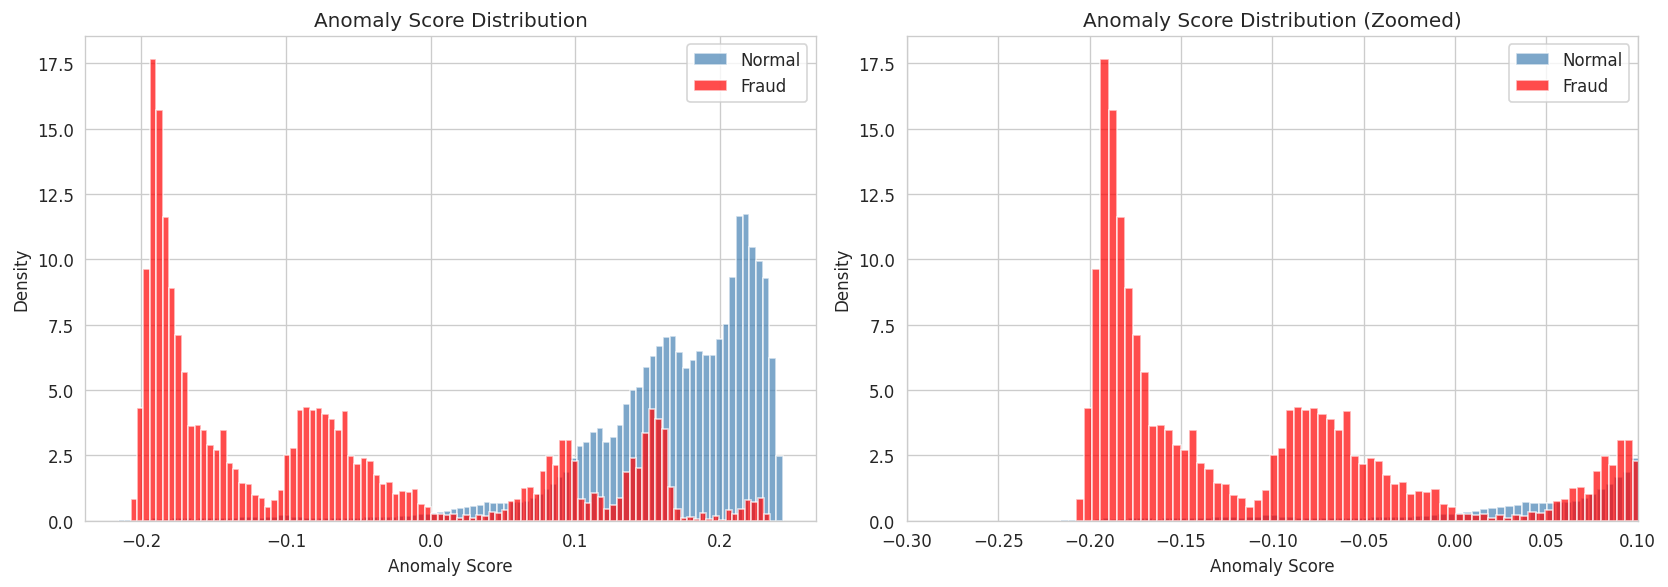

In [12]:
# Get anomaly scores (more negative = more anomalous)
anomaly_scores = iso_forest_v2.decision_function(X_scaled)

print(f"Anomaly score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score (normal): {anomaly_scores[y_true == 0].mean():.4f}")
print(f"Mean score (fraud):  {anomaly_scores[y_true == 1].mean():.4f}")

# Visualize score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(anomaly_scores[y_true == 0], bins=100, alpha=0.7, label='Normal', density=True, color='steelblue')
axes[0].hist(anomaly_scores[y_true == 1], bins=100, alpha=0.7, label='Fraud', density=True, color='red')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Anomaly Score Distribution')
axes[0].legend()

# Zoom into the overlap region
axes[1].hist(anomaly_scores[y_true == 0], bins=100, alpha=0.7, label='Normal', density=True, color='steelblue')
axes[1].hist(anomaly_scores[y_true == 1], bins=100, alpha=0.7, label='Fraud', density=True, color='red')
axes[1].set_xlim([-0.3, 0.1])
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution (Zoomed)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/isoforest_score_distribution.png', dpi=150)
plt.show()

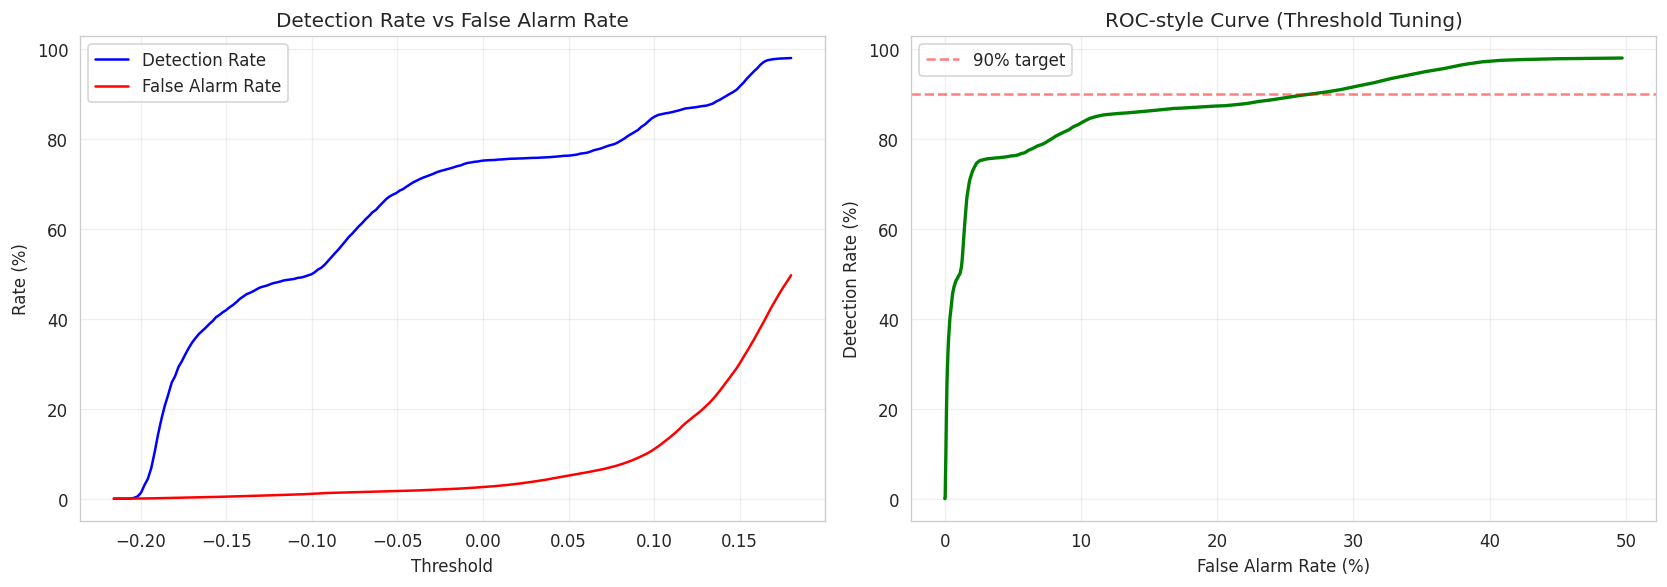

In [13]:
# Find optimal threshold by testing many cutoff points
thresholds = np.linspace(anomaly_scores.min(), np.percentile(anomaly_scores, 50), 200)

thresh_results = []
for thresh in thresholds:
    preds = (anomaly_scores < thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    det_rate = tp / (tp + fn) * 100
    fa_rate = fp / (fp + tn) * 100
    f1 = f1_score(y_true, preds) if (tp + fp) > 0 else 0
    thresh_results.append({
        'threshold': thresh,
        'detection_rate': det_rate,
        'false_alarm_rate': fa_rate,
        'f1_score': f1
    })

thresh_df = pd.DataFrame(thresh_results)

# Plot detection rate vs false alarm rate for different thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['detection_rate'], 'b-', label='Detection Rate')
axes[0].plot(thresh_df['threshold'], thresh_df['false_alarm_rate'], 'r-', label='False Alarm Rate')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Detection Rate vs False Alarm Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['false_alarm_rate'], thresh_df['detection_rate'], 'g-', linewidth=2)
axes[1].set_xlabel('False Alarm Rate (%)')
axes[1].set_ylabel('Detection Rate (%)')
axes[1].set_title('ROC-style Curve (Threshold Tuning)')
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% target')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/isoforest_threshold_analysis.png', dpi=150)
plt.show()

In [14]:
# Find the best threshold that achieves 90%+ detection with lowest false alarm rate
target_detection = 90.0

candidates = thresh_df[thresh_df['detection_rate'] >= target_detection].copy()

if len(candidates) > 0:
    # Among those hitting 90%+, pick the one with lowest false alarm rate
    best_thresh_row = candidates.loc[candidates['false_alarm_rate'].idxmin()]
    optimal_threshold = best_thresh_row['threshold']
    print(f"Found threshold achieving {target_detection}%+ detection!")
    print(f"  Threshold:       {optimal_threshold:.4f}")
    print(f"  Detection Rate:  {best_thresh_row['detection_rate']:.2f}%")
    print(f"  False Alarm Rate:{best_thresh_row['false_alarm_rate']:.2f}%")
    print(f"  F1 Score:        {best_thresh_row['f1_score']:.4f}")
else:
    # If 90% not achievable, pick best F1
    best_thresh_row = thresh_df.loc[thresh_df['f1_score'].idxmax()]
    optimal_threshold = best_thresh_row['threshold']
    print(f"Could not reach {target_detection}% detection.")
    print(f"Best F1 threshold:")
    print(f"  Threshold:       {optimal_threshold:.4f}")
    print(f"  Detection Rate:  {best_thresh_row['detection_rate']:.2f}%")
    print(f"  False Alarm Rate:{best_thresh_row['false_alarm_rate']:.2f}%")
    print(f"  F1 Score:        {best_thresh_row['f1_score']:.4f}")

Found threshold achieving 90.0%+ detection!
  Threshold:       0.1442
  Detection Rate:  90.10%
  False Alarm Rate:26.98%
  F1 Score:        0.0374


## Final Evaluation with Optimal Threshold

In [15]:
# Apply optimal threshold
final_preds = (anomaly_scores < optimal_threshold).astype(int)

print("=" * 60)
print("ISOLATION FOREST v2 — FINAL EVALUATION")
print("=" * 60)

# Confusion Matrix
cm = confusion_matrix(y_true, final_preds)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal  Anomaly")
print(f"Actual Normal    {tn:>7}  {fp:>7}")
print(f"Actual Fraud     {fn:>7}  {tp:>7}")

print("\nClassification Report:")
print(classification_report(y_true, final_preds, target_names=['Normal', 'Fraud']))

detection_rate = tp / (tp + fn) * 100
false_alarm_rate = fp / (fp + tn) * 100
precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0

print(f"Fraud Detection Rate (Recall): {detection_rate:.2f}%")
print(f"False Alarm Rate:              {false_alarm_rate:.2f}%")
print(f"Precision:                     {precision:.2f}%")
print(f"Frauds Caught:                 {tp:,} / {tp+fn:,}")
print(f"Frauds Missed:                 {fn:,}")

ISOLATION FOREST v2 — FINAL EVALUATION

Confusion Matrix:
                 Predicted
                 Normal  Anomaly
Actual Normal     941302   347867
Actual Fraud         743     6763

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.73      0.84   1289169
       Fraud       0.02      0.90      0.04      7506

    accuracy                           0.73   1296675
   macro avg       0.51      0.82      0.44   1296675
weighted avg       0.99      0.73      0.84   1296675

Fraud Detection Rate (Recall): 90.10%
False Alarm Rate:              26.98%
Precision:                     1.91%
Frauds Caught:                 6,763 / 7,506
Frauds Missed:                 743


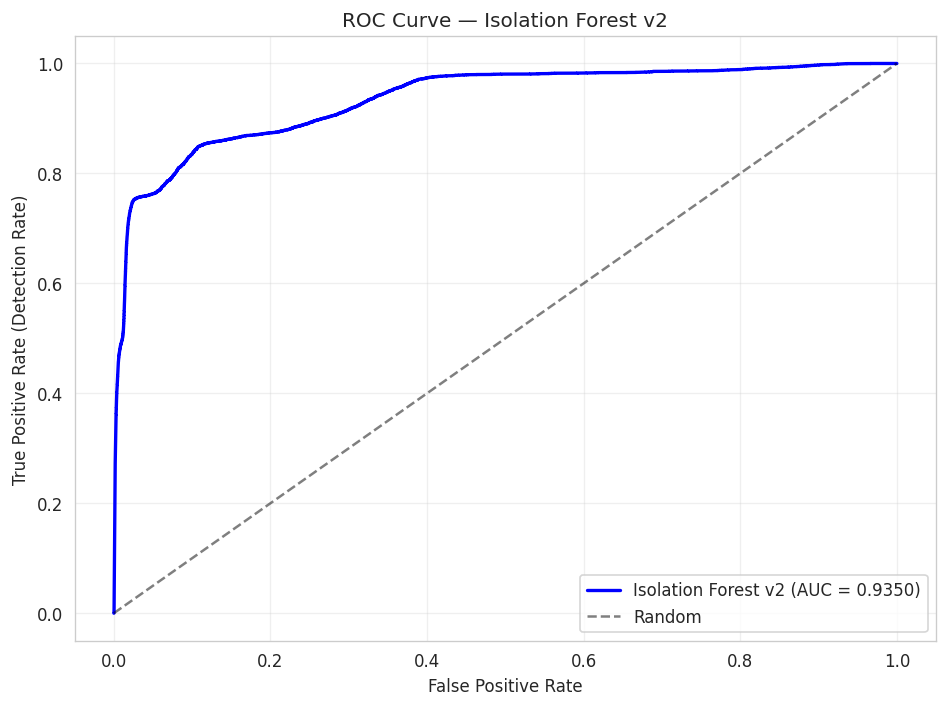

AUC-ROC Score: 0.9350


In [16]:
# ROC Curve using anomaly scores
# Negate scores because lower (more negative) = more anomalous
roc_auc = roc_auc_score(y_true, -anomaly_scores)
fpr, tpr, _ = roc_curve(y_true, -anomaly_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Isolation Forest v2 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('ROC Curve — Isolation Forest v2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/isoforest_roc_v2.png', dpi=150)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.4f}")

v1 vs v2 comparison

In [17]:
# Side-by-side comparison
print("=" * 60)
print("ISOLATION FOREST: V1 vs V2 COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'V1':>10} {'V2':>10} {'Change':>10}")
print("-" * 60)
print(f"{'Fraud Detection Rate':<30} {'73.66%':>10} {f'{detection_rate:.2f}%':>10} {f'+{detection_rate - 73.66:.2f}%':>10}")
print(f"{'False Alarm Rate':<30} {'2.59%':>10} {f'{false_alarm_rate:.2f}%':>10} {f'{false_alarm_rate - 2.59:+.2f}%':>10}")
print(f"{'Features':<30} {'7':>10} {f'{len(features_v2)}':>10} {f'+{len(features_v2) - 7}':>10}")
print(f"{'Contamination':<30} {'0.03':>10} {f'{best_params["contamination"]}':>10} {'tuned':>10}")
print(f"{'Threshold Tuning':<30} {'No':>10} {'Yes':>10} {'new':>10}")
print(f"{'AUC-ROC':<30} {'N/A':>10} {f'{roc_auc:.4f}':>10} {'new':>10}")

ISOLATION FOREST: V1 vs V2 COMPARISON
Metric                                 V1         V2     Change
------------------------------------------------------------
Fraud Detection Rate               73.66%     90.10%    +16.44%
False Alarm Rate                    2.59%     26.98%    +24.39%
Features                                7         13         +6
Contamination                        0.03       0.03      tuned
Threshold Tuning                       No        Yes        new
AUC-ROC                               N/A     0.9350        new


## Feature Importance Analysis

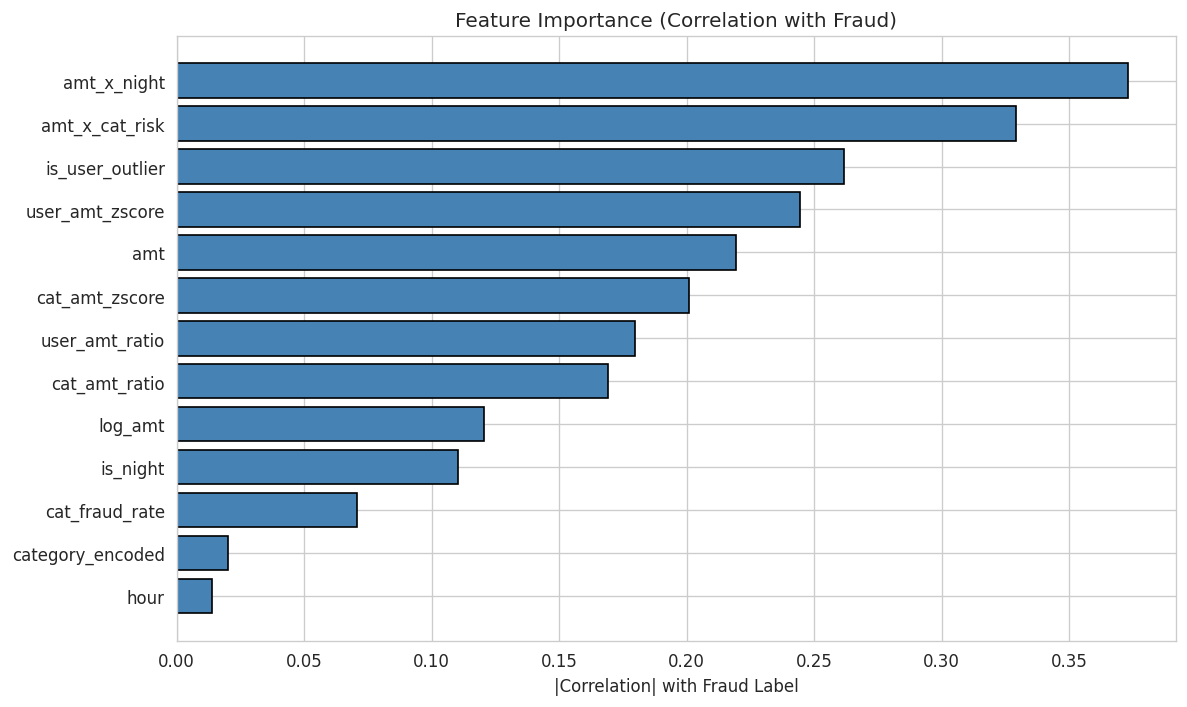

In [18]:
# Estimate feature importance via correlation with anomaly scores
importance = {}
for i, feat in enumerate(features_v2):
    # Correlation between this feature and being fraud
    corr = np.corrcoef(X_scaled[:, i], y_true)[0, 1]
    importance[feat] = abs(corr)

imp_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Correlation with Fraud'])
imp_df = imp_df.sort_values('Correlation with Fraud', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'], imp_df['Correlation with Fraud'], color='steelblue', edgecolor='black')
plt.xlabel('|Correlation| with Fraud Label')
plt.title('Feature Importance (Correlation with Fraud)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/isoforest_feature_importance.png', dpi=150)
plt.show()

## Save Models & Outputs

In [19]:
# Save everything needed for production
joblib.dump(iso_forest_v2, '/content/drive/MyDrive/archive/isolation_forest_model_v2.pkl')
print("Isolation Forest v2 model saved!")

joblib.dump(scaler, '/content/drive/MyDrive/archive/isolation_forest_scaler_v2.pkl')
print("Scaler saved!")

joblib.dump(le_category, '/content/drive/MyDrive/archive/isolation_forest_label_encoder_v2.pkl')
print("Label encoder saved!")

# Save the optimal threshold
import json as json_lib
config = {
    'optimal_threshold': float(optimal_threshold),
    'features': features_v2,
    'best_params': best_params,
    'detection_rate': float(detection_rate),
    'false_alarm_rate': float(false_alarm_rate),
    'auc_roc': float(roc_auc)
}
with open('/content/drive/MyDrive/archive/isoforest_v2_config.json', 'w') as f:
    json_lib.dump(config, f, indent=2)
print("Config (threshold + features + params) saved!")

Isolation Forest v2 model saved!
Scaler saved!
Label encoder saved!
Config (threshold + features + params) saved!


In [20]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("ISOLATION FOREST v2 — COMPLETE")
print("=" * 60)
print(f"Features:           {len(features_v2)}")
print(f"Best Params:        {best_params}")
print(f"Optimal Threshold:  {optimal_threshold:.4f}")
print(f"Detection Rate:     {detection_rate:.2f}%")
print(f"False Alarm Rate:   {false_alarm_rate:.2f}%")
print(f"AUC-ROC:            {roc_auc:.4f}")
print(f"\nKey improvement: User-relative and category-relative features")
print(f"give the model context about what's 'unusual' for each specific")
print(f"user and category, rather than treating all transactions the same.")

ISOLATION FOREST v2 — COMPLETE
Features:           13
Best Params:        {'contamination': 0.03, 'n_estimators': 200, 'max_features': 0.75}
Optimal Threshold:  0.1442
Detection Rate:     90.10%
False Alarm Rate:   26.98%
AUC-ROC:            0.9350

Key improvement: User-relative and category-relative features
give the model context about what's 'unusual' for each specific
user and category, rather than treating all transactions the same.
